# NIQE Step-by-Step in Google Colab

This notebook explains and implements the main stages behind the **Natural Image Quality Evaluator (NIQE)**, a no-reference image quality assessment metric.

NIQE estimates image quality without requiring a pristine reference image and without relying on human opinion scores for the test image. It is based on **Natural Scene Statistics (NSS)** and compares the statistical behavior of the input image with a statistical model learned from natural, undistorted images.

In this notebook you will:

1. Upload an image from your computer.
2. Display the original image.
3. Convert the image to grayscale/luminance.
4. Compute MSCN coefficients.
5. Visualize the local mean, local standard deviation, and MSCN map.
6. Divide the image into local patches.
7. Select spatially active patches.
8. Extract NSS/BRISQUE-like features from selected patches.
9. Build a Multivariate Gaussian (MVG) model from the test image features.
10. Compute the final **NIQE score** using a standard implementation.

> **Important note:** This notebook is for **NIQE**, not BRISQUE.  
> BRISQUE uses a supervised regression model trained with subjective quality scores.  
> NIQE compares the image statistics against a natural-image statistical model.

In [1]:
# ============================================================
# 1. Install and import required libraries
# ============================================================

!pip -q install opencv-python-headless scipy pandas matplotlib pillow torch torchvision piq

import os
import cv2
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from scipy.ndimage import convolve
from scipy.special import gamma
from google.colab import files
from IPython.display import display

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("OpenCV version:", cv2.__version__)
print("PIQ version:", piq.__version__ if hasattr(piq, "__version__") else "installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 2.3 MB/s eta 0:00:00
OpenCV version: 4.13.0
PIQ version: 0.8.0


## 2. Upload an image from your computer

Run the next cell and select one image file from your PC.

Saving original.jpg to original.jpg
Uploaded image: original.jpg


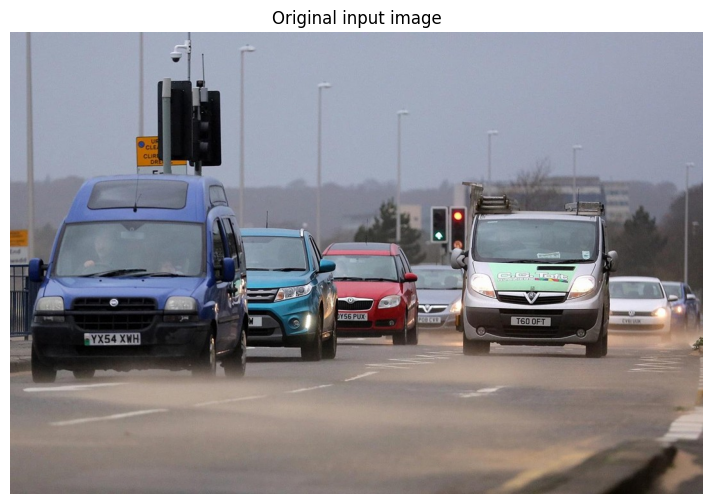

Image shape: (720, 1080, 3)


In [2]:
# ============================================================
# 2. Upload image from PC
# ============================================================

uploaded = files.upload()

image_path = list(uploaded.keys())[0]
print("Uploaded image:", image_path)

img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise ValueError("The image could not be read. Please upload a valid image file.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(9, 6))
plt.imshow(img_rgb)
plt.title("Original input image")
plt.axis("off")
plt.show()

print("Image shape:", img_rgb.shape)

## 3. Convert the image to luminance/grayscale

NIQE uses natural scene statistics extracted from luminance information.  
For this reason, the image is converted to grayscale.

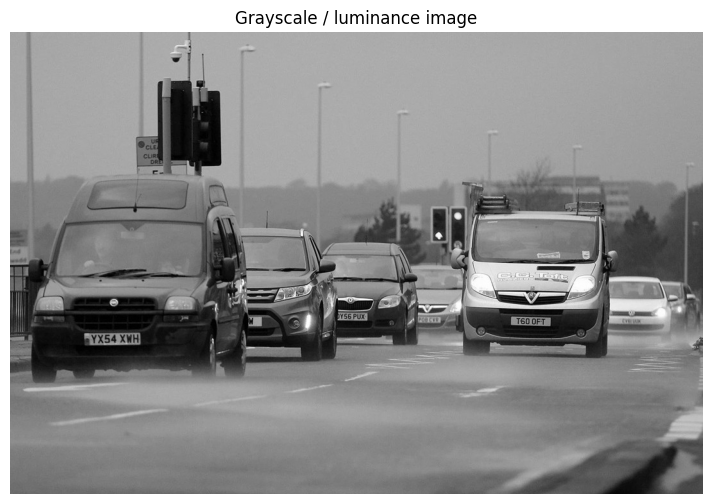

Grayscale image size: (720, 1080)


In [3]:
# ============================================================
# 3. Convert to grayscale/luminance
# ============================================================

gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float64)

plt.figure(figsize=(9, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale / luminance image")
plt.axis("off")
plt.show()

print("Grayscale image size:", gray.shape)

## 4. Compute MSCN coefficients

The first key step in NIQE is local mean removal and divisive normalization.  
This produces **Mean Subtracted Contrast Normalized (MSCN)** coefficients:

\[
\hat{I}(i,j)=\frac{I(i,j)-\mu(i,j)}{\sigma(i,j)+C}
\]

where:

- \(I(i,j)\) is the luminance value at pixel location \((i,j)\).
- \(\mu(i,j)\) is the local mean.
- \(\sigma(i,j)\) is the local standard deviation.
- \(C\) avoids division by zero.

MSCN coefficients reduce local brightness and contrast variations, allowing the model to analyze natural image statistics more clearly.

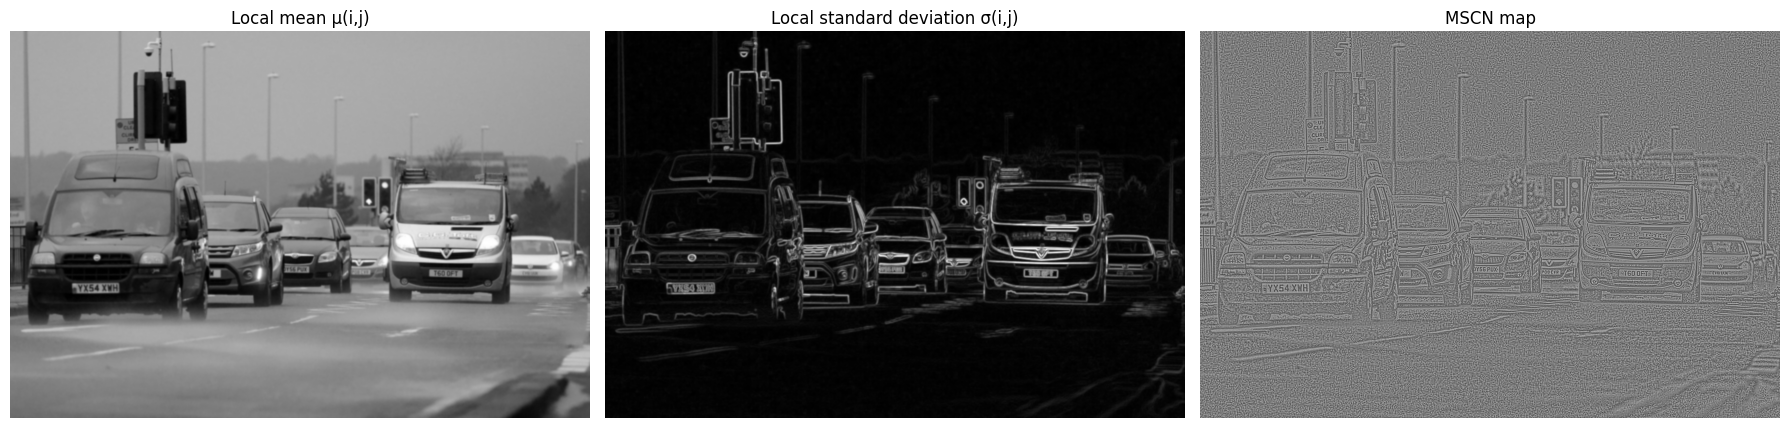

MSCN statistics:
Mean: -9.778530208219339e-05
Standard deviation: 0.4551830350042191
Minimum: -1.9870103323742883
Maximum: 2.105362683100672


In [4]:
# ============================================================
# 4. MSCN computation
# ============================================================

def gaussian_kernel_2d(size=7, sigma=7/6):
    # Creates a normalized 2D Gaussian kernel.
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel

def compute_mscn_coefficients(image, C=1.0, kernel_size=7, sigma=7/6):
    # Computes MSCN coefficients:
    # I_hat(i,j) = [I(i,j) - mu(i,j)] / [sigma(i,j) + C]
    image = image.astype(np.float64)
    kernel = gaussian_kernel_2d(kernel_size, sigma)

    local_mean = convolve(image, kernel, mode="reflect")
    local_var = convolve(image**2, kernel, mode="reflect") - local_mean**2
    local_var = np.maximum(local_var, 0)
    local_std = np.sqrt(local_var)

    mscn = (image - local_mean) / (local_std + C)
    return mscn, local_mean, local_std

mscn, local_mean, local_std = compute_mscn_coefficients(gray)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].imshow(local_mean, cmap="gray")
axs[0].set_title("Local mean μ(i,j)")
axs[0].axis("off")

axs[1].imshow(local_std, cmap="gray")
axs[1].set_title("Local standard deviation σ(i,j)")
axs[1].axis("off")

axs[2].imshow(mscn, cmap="gray")
axs[2].set_title("MSCN map")
axs[2].axis("off")

plt.tight_layout()
plt.show()

print("MSCN statistics:")
print("Mean:", np.mean(mscn))
print("Standard deviation:", np.std(mscn))
print("Minimum:", np.min(mscn))
print("Maximum:", np.max(mscn))

## 5. Visualize the MSCN coefficient distribution

For natural images with little distortion, MSCN coefficients tend to follow a regular Gaussian-like distribution.  
Distortions modify this distribution, and NIQE uses these deviations to estimate quality.

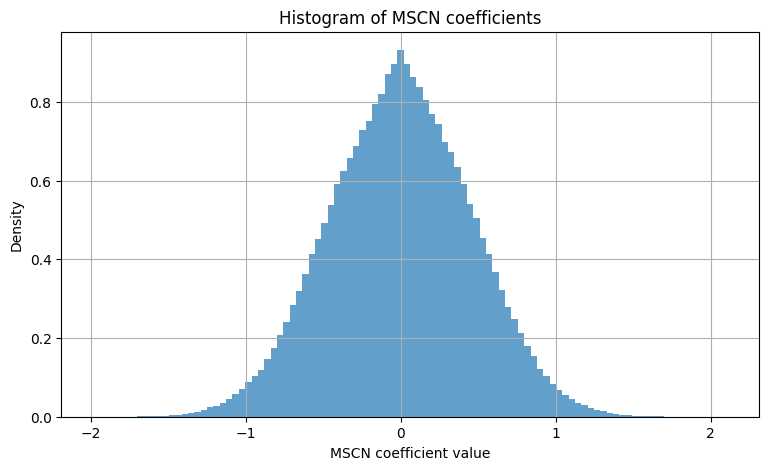

In [5]:
# ============================================================
# 5. MSCN histogram
# ============================================================

coeff = mscn.flatten()
coeff = coeff[np.isfinite(coeff)]
coeff_plot = coeff[(coeff > -5) & (coeff < 5)]

plt.figure(figsize=(9, 5))
plt.hist(coeff_plot, bins=100, density=True, alpha=0.7)
plt.title("Histogram of MSCN coefficients")
plt.xlabel("MSCN coefficient value")
plt.ylabel("Density")
plt.show()

## 6. Divide the image into local patches

NIQE works with local image patches.  
The original NIQE method analyzes patches and selects those that are more informative or spatially active.

In this notebook, patches are generated from the grayscale image and visualized as a grid.

Cropped image size: (672, 1056)
Patch size: 96 x 96
Number of patches: 77


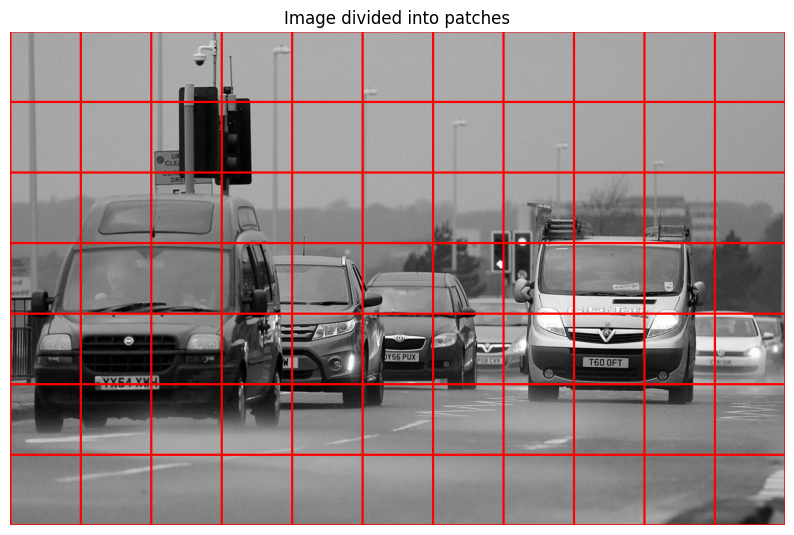

In [6]:
# ============================================================
# 6. Divide image into patches
# ============================================================

PATCH_SIZE = 96

def crop_to_multiple(image, patch_size):
    h, w = image.shape[:2]
    new_h = (h // patch_size) * patch_size
    new_w = (w // patch_size) * patch_size
    return image[:new_h, :new_w]

gray_cropped = crop_to_multiple(gray, PATCH_SIZE)
mscn_cropped = crop_to_multiple(mscn, PATCH_SIZE)
local_std_cropped = crop_to_multiple(local_std, PATCH_SIZE)

h, w = gray_cropped.shape
num_rows = h // PATCH_SIZE
num_cols = w // PATCH_SIZE

print("Cropped image size:", gray_cropped.shape)
print("Patch size:", PATCH_SIZE, "x", PATCH_SIZE)
print("Number of patches:", num_rows * num_cols)

# Create a visual grid over the grayscale image
grid_img = cv2.cvtColor(gray_cropped.astype(np.uint8), cv2.COLOR_GRAY2RGB)

for y in range(0, h + 1, PATCH_SIZE):
    cv2.line(grid_img, (0, y), (w, y), (255, 0, 0), 2)

for x in range(0, w + 1, PATCH_SIZE):
    cv2.line(grid_img, (x, 0), (x, h), (255, 0, 0), 2)

plt.figure(figsize=(10, 7))
plt.imshow(grid_img)
plt.title("Image divided into patches")
plt.axis("off")
plt.show()

## 7. Select spatially active patches

NIQE gives importance to informative patches.  
One way to identify informative regions is to compute local activity or sharpness.

Here, the local activity of each patch is estimated using the average local standard deviation.  
Patches with higher activity are selected because they contain more structure, texture, or detail.

Maximum activity: 28.419913954306796
Activity threshold: 21.3149354657301
Selected patches: 2 out of 77


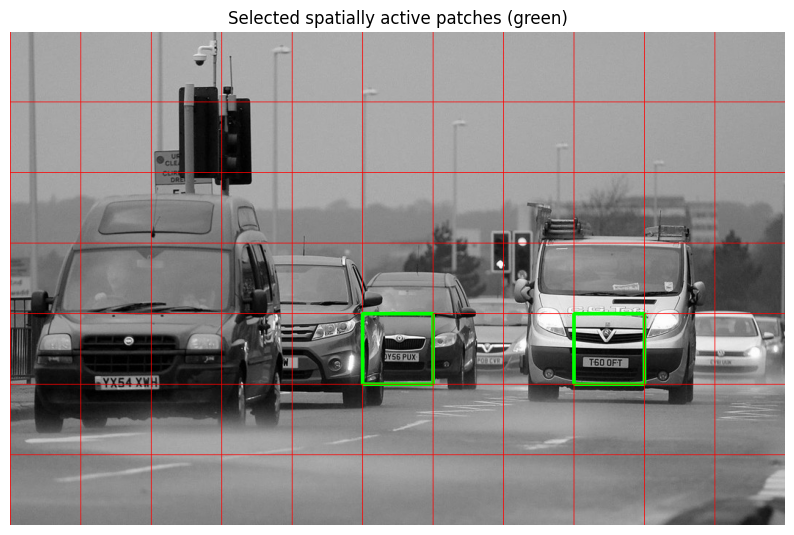

,Patch index,Activity,Selected
0,1,2.007778,False
1,2,1.297153,False
2,3,8.162412,False
3,4,4.639479,False
4,5,1.210060,False
...,...,...,...
72,73,1.535742,False
73,74,1.608186,False
74,75,1.806272,False
75,76,2.541111,False


In [7]:
# ============================================================
# 7. Spatially active patch selection
# ============================================================

patch_activity = []
patch_positions = []

for r in range(num_rows):
    for c in range(num_cols):
        y0 = r * PATCH_SIZE
        x0 = c * PATCH_SIZE
        patch_std = local_std_cropped[y0:y0+PATCH_SIZE, x0:x0+PATCH_SIZE]
        activity = np.mean(patch_std)
        patch_activity.append(activity)
        patch_positions.append((x0, y0))

patch_activity = np.array(patch_activity)

# Threshold as a fraction of the maximum patch activity.
# The NIQE paper uses a threshold based on the peak patch sharpness.
threshold_fraction = 0.75
activity_threshold = threshold_fraction * np.max(patch_activity)

selected = patch_activity >= activity_threshold

print("Maximum activity:", np.max(patch_activity))
print("Activity threshold:", activity_threshold)
print("Selected patches:", np.sum(selected), "out of", len(selected))

# Visualize selected patches
selected_img = cv2.cvtColor(gray_cropped.astype(np.uint8), cv2.COLOR_GRAY2RGB)

for idx, (x0, y0) in enumerate(patch_positions):
    color = (0, 255, 0) if selected[idx] else (255, 0, 0)
    thickness = 3 if selected[idx] else 1
    cv2.rectangle(
        selected_img,
        (x0, y0),
        (x0 + PATCH_SIZE, y0 + PATCH_SIZE),
        color,
        thickness
    )

plt.figure(figsize=(10, 7))
plt.imshow(selected_img)
plt.title("Selected spatially active patches (green)")
plt.axis("off")
plt.show()

activity_df = pd.DataFrame({
    "Patch index": np.arange(1, len(patch_activity) + 1),
    "Activity": patch_activity,
    "Selected": selected
})
display(activity_df)

## 8. Extract NSS features from selected patches

NIQE uses quality-aware NSS features.  
These features are similar to those used in BRISQUE: GGD parameters from MSCN coefficients and AGGD parameters from pairwise products of neighboring MSCN coefficients.

At each patch, the model extracts statistical features from:

1. MSCN coefficients.
2. Pairwise products in four orientations:
   - Horizontal
   - Vertical
   - Main diagonal
   - Secondary diagonal

In [8]:
# ============================================================
# 8. NSS feature extraction functions
# ============================================================

def estimate_ggd_parameters(vec):
    # Estimates GGD shape parameter alpha and variance sigma^2.
    vec = vec.flatten()
    vec = vec[np.isfinite(vec)]

    if len(vec) == 0 or np.mean(vec ** 2) == 0:
        return 0, 0

    gammas = np.arange(0.2, 10, 0.001)
    r_gam = (gamma(2/gammas) ** 2) / (gamma(1/gammas) * gamma(3/gammas))

    sigma_sq = np.mean(vec ** 2)
    E = np.mean(np.abs(vec))
    rho = (E ** 2) / sigma_sq

    alpha = gammas[np.argmin(np.abs(r_gam - rho))]
    return alpha, sigma_sq

def pairwise_products(mscn_patch):
    H = mscn_patch[:, :-1] * mscn_patch[:, 1:]
    V = mscn_patch[:-1, :] * mscn_patch[1:, :]
    D1 = mscn_patch[:-1, :-1] * mscn_patch[1:, 1:]
    D2 = mscn_patch[:-1, 1:] * mscn_patch[1:, :-1]
    return H, V, D1, D2

def estimate_aggd_parameters(vec):
    # Estimates AGGD parameters for pairwise product distributions.
    vec = vec.flatten()
    vec = vec[np.isfinite(vec)]

    if len(vec) == 0 or np.mean(vec ** 2) == 0:
        return 0, 0, 0, 0

    left_data = vec[vec < 0]
    right_data = vec[vec > 0]

    left_std = np.sqrt(np.mean(left_data ** 2)) if len(left_data) > 0 else 0
    right_std = np.sqrt(np.mean(right_data ** 2)) if len(right_data) > 0 else 0

    if right_std == 0:
        right_std = 1e-6

    gamma_hat = left_std / right_std

    r_hat = (np.mean(np.abs(vec)) ** 2) / np.mean(vec ** 2)
    r_hat_norm = (r_hat * (gamma_hat ** 3 + 1) * (gamma_hat + 1)) / ((gamma_hat ** 2 + 1) ** 2)

    gammas = np.arange(0.2, 10, 0.001)
    r_gam = (gamma(2/gammas) ** 2) / (gamma(1/gammas) * gamma(3/gammas))

    alpha = gammas[np.argmin(np.abs(r_gam - r_hat_norm))]

    beta_l = left_std * np.sqrt(gamma(1/alpha) / gamma(3/alpha)) if left_std > 0 else 0
    beta_r = right_std * np.sqrt(gamma(1/alpha) / gamma(3/alpha)) if right_std > 0 else 0

    mean_param = (beta_r - beta_l) * (gamma(2/alpha) / gamma(1/alpha))
    left_variance = left_std ** 2
    right_variance = right_std ** 2

    return alpha, mean_param, left_variance, right_variance

def nss_features_one_patch(mscn_patch):
    features = []

    # 2 features from GGD fit of MSCN coefficients
    alpha, sigma_sq = estimate_ggd_parameters(mscn_patch)
    features.extend([alpha, sigma_sq])

    # 16 features from AGGD fit of pairwise products
    H, V, D1, D2 = pairwise_products(mscn_patch)
    for product in [H, V, D1, D2]:
        alpha, mean_param, left_var, right_var = estimate_aggd_parameters(product)
        features.extend([alpha, mean_param, left_var, right_var])

    return np.array(features)

## 9. Extract patch-level features and build a test-image feature model

For each selected patch, NSS features are extracted.  
Then, the distribution of those features in the test image is represented using a **Multivariate Gaussian (MVG)** model:

\[
f_X(x)=\frac{1}{(2\pi)^{k/2}|\Sigma|^{1/2}}
\exp\left[-\frac{1}{2}(x-\nu)^T\Sigma^{-1}(x-\nu)\right]
\]

where:

- \(x\) is the feature vector.
- \(\nu\) is the mean vector.
- \(\Sigma\) is the covariance matrix.

NIQE compares this test-image MVG model with a natural-image MVG model learned from pristine natural images.

In [9]:
# ============================================================
# 9. Patch-level NSS features and test MVG model
# ============================================================

patch_features = []

for idx, (x0, y0) in enumerate(patch_positions):
    if selected[idx]:
        patch_mscn = mscn_cropped[y0:y0+PATCH_SIZE, x0:x0+PATCH_SIZE]
        feat = nss_features_one_patch(patch_mscn)
        patch_features.append(feat)

patch_features = np.array(patch_features)

if patch_features.shape[0] < 2:
    print("Warning: very few active patches were selected. Selecting all patches instead.")
    patch_features = []
    for idx, (x0, y0) in enumerate(patch_positions):
        patch_mscn = mscn_cropped[y0:y0+PATCH_SIZE, x0:x0+PATCH_SIZE]
        feat = nss_features_one_patch(patch_mscn)
        patch_features.append(feat)
    patch_features = np.array(patch_features)

print("Patch feature matrix shape:", patch_features.shape)

feature_names = [
    "MSCN alpha", "MSCN variance",
    "H alpha", "H mean", "H left variance", "H right variance",
    "V alpha", "V mean", "V left variance", "V right variance",
    "D1 alpha", "D1 mean", "D1 left variance", "D1 right variance",
    "D2 alpha", "D2 mean", "D2 left variance", "D2 right variance"
]

df_patch_features = pd.DataFrame(patch_features, columns=feature_names)
display(df_patch_features)

test_mean = np.mean(patch_features, axis=0)
test_cov = np.cov(patch_features, rowvar=False)

print("Test-image MVG mean vector shape:", test_mean.shape)
print("Test-image MVG covariance matrix shape:", test_cov.shape)

Patch feature matrix shape: (2, 18)


,MSCN alpha,MSCN variance,H alpha,H mean,H left variance,H right variance,V alpha,V mean,V left variance,V right variance,D1 alpha,D1 mean,D1 left variance,D1 right variance,D2 alpha,D2 mean,D2 left variance,D2 right variance
0,2.600,0.319744,0.741,0.009852,0.130632,0.141865,0.756,0.111883,0.063164,0.178919,0.821,-0.078658,0.145844,0.069896,0.801,-0.048940,0.130982,0.083076
1,2.591,0.319240,0.738,0.084910,0.103996,0.205968,0.829,0.003873,0.100312,0.104000,0.949,-0.048560,0.115146,0.072753,0.908,-0.060633,0.126122,0.071385


Test-image MVG mean vector shape: (18,)
Test-image MVG covariance matrix shape: (18, 18)


## 10. Visualize the feature behavior

The following plots show how some NSS features vary across the selected patches.

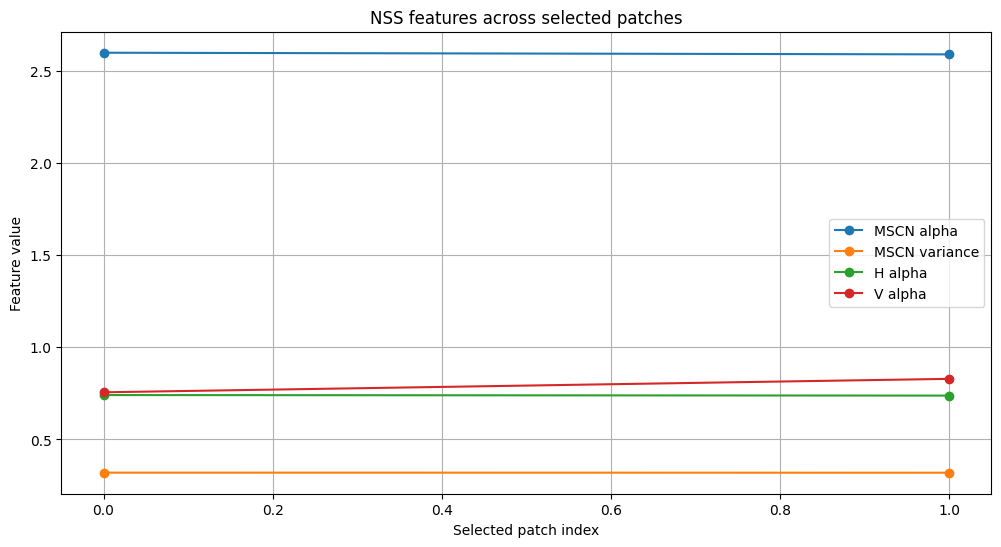

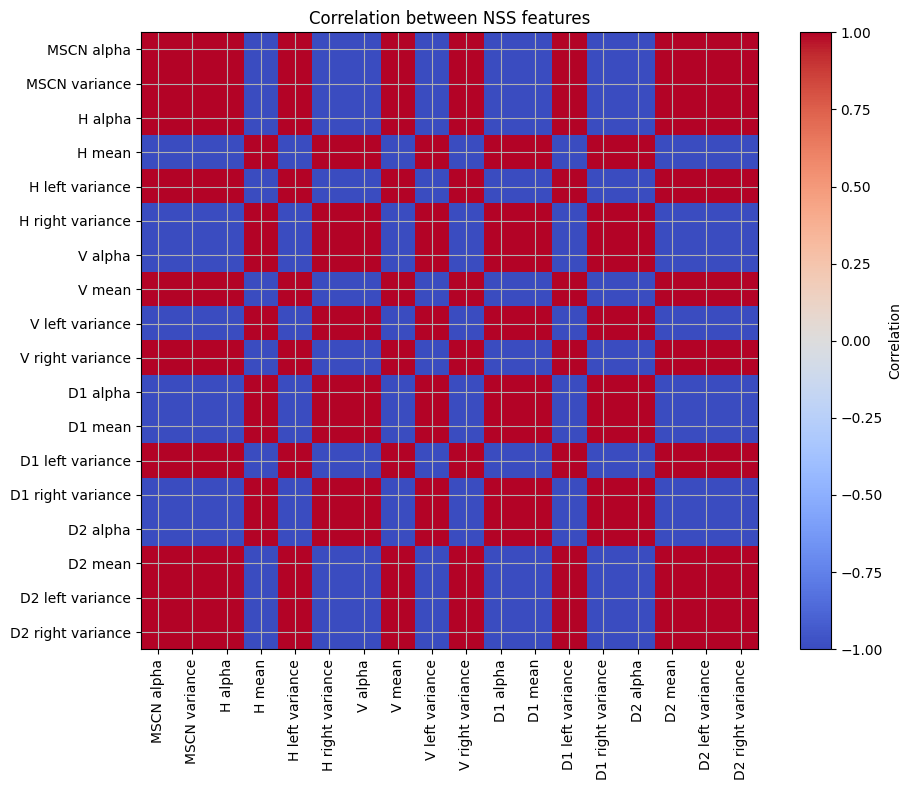

In [10]:
# ============================================================
# 10. Feature visualization
# ============================================================

selected_features_to_plot = ["MSCN alpha", "MSCN variance", "H alpha", "V alpha"]

plt.figure(figsize=(12, 6))
for feature in selected_features_to_plot:
    plt.plot(df_patch_features[feature].values, marker="o", label=feature)

plt.title("NSS features across selected patches")
plt.xlabel("Selected patch index")
plt.ylabel("Feature value")
plt.legend()
plt.show()

# Show correlation heatmap of features
corr = df_patch_features.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Correlation between NSS features")
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.yticks(range(len(feature_names)), feature_names)
plt.tight_layout()
plt.show()

## 11. Compute the final NIQE score

The previous steps explain the internal logic of NIQE: MSCN coefficients, patch selection, NSS features, and MVG modeling.

For the final NIQE score, this notebook uses the `piq` library, which provides a standard implementation of NIQE.

**Interpretation:** lower NIQE values usually indicate better perceptual quality, while higher values indicate lower perceptual quality.

In [13]:
# ============================================================
# 11. Final NIQE score using pyiqa
# ============================================================

!pip -q install pyiqa

import pyiqa
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert RGB image to PyTorch tensor in range [0, 1]
img_tensor = torch.tensor(img_rgb).permute(2, 0, 1).unsqueeze(0).float() / 255.0
img_tensor = img_tensor.to(device)

# Create NIQE metric
niqe_metric = pyiqa.create_metric("niqe", device=device)

with torch.no_grad():
    niqe_score = niqe_metric(img_tensor)

niqe_value = float(niqe_score.item())

print("Final NIQE score:", niqe_value)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44

100%|██████████| 8.15k/8.15k [00:00<00:00, 17.5MB/s]


Final NIQE score: 3.4298486848266614


## 12. Visual interpretation of the NIQE score

There is no universal fixed threshold for all datasets, but in general:

- Lower NIQE score → better natural perceptual quality.
- Higher NIQE score → stronger deviation from natural image statistics.

The exact interpretation depends on the image content, resolution, and acquisition conditions.

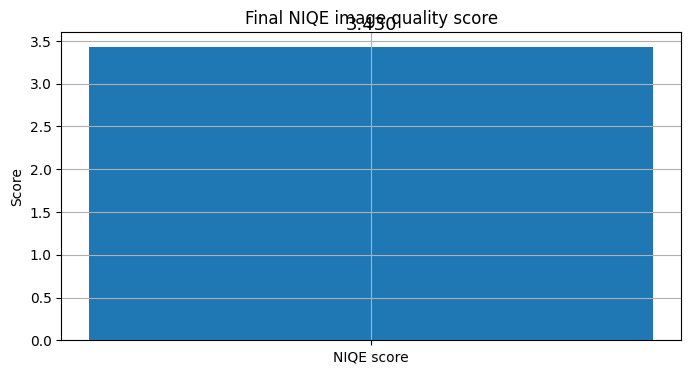

Interpretation:
Lower NIQE values usually indicate better perceptual image quality.
Higher NIQE values indicate a greater deviation from natural image statistics.


In [14]:
# ============================================================
# 12. Plot final NIQE score
# ============================================================

plt.figure(figsize=(8, 4))
plt.bar(["NIQE score"], [niqe_value])
plt.ylabel("Score")
plt.title("Final NIQE image quality score")

for i, v in enumerate([niqe_value]):
    plt.text(i, v + 0.2, f"{v:.3f}", ha="center", fontsize=13)

plt.show()

print("Interpretation:")
print("Lower NIQE values usually indicate better perceptual image quality.")
print("Higher NIQE values indicate a greater deviation from natural image statistics.")

## 13. Complete NIQE workflow summary

The complete NIQE workflow can be summarized as:

\[
Image \rightarrow Grayscale \rightarrow MSCN \rightarrow Patch Selection \rightarrow NSS Features \rightarrow MVG Model \rightarrow NIQE Score
\]

In simple terms:

1. The image is converted to grayscale.
2. MSCN coefficients are computed to normalize luminance and contrast.
3. Informative patches are selected.
4. NSS features are extracted from those patches.
5. A statistical MVG model is built for the test image.
6. The test-image model is compared with a natural-image model.
7. The final NIQE score is obtained.